# **Project: E-commerce Analytics & Consumer Behavior Intelligence.**

**Internship Domain:** Python Data Analytics with AI.

**Dataset:** [UCI Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail)


# **Phase 1: Requirements Analysis and Business Problem Identification**
- **Problem Statement:** Although the e-commerce store attracts significant traffic, it encounters difficulties in converting visitors into high-value customers, strengthening customer retention, and optimizing profit margins.

- **KPIs (Success Metrics):**
  - **Revenue Trends:** Examine revenue patterns over time (daily, monthly, or seasonal) to identify peak sales periods.  
  - **Average Order Value (AOV):** Calculate by dividing total revenue by the number of orders.  
  - **Customer Segmentation (VIP Identification):** Classify customers to identify high-value segments based on revenue contribution or RFM analysis.  
  - **Customer Churn Risk:** Identify customers who have not made any purchases within the last 90 days.  
  - **Repeat Purchase Rate:** Measure the percentage of customers who have made more than one purchase.  
  - **Product Performance:** Analyze products to determine top-selling items and those generating the highest revenue.  
  - **Customer Lifetime Value (CLV):** Estimate the total value of a customer based on their historical spending behavior.  

- **Goal:** Leverage customer behavior and sales insights to design three data-driven strategies aimed at increasing overall revenue by 10% within a six-month period.

# **Phase 2: Data Acquisition & Pre-processing**
### **Approach:**
**1. Data Collection:**
- Import the Online Retail transactional dataset from the UCI repository into the analysis environment.

### **2. Data Cleaning:**

- Exclude records with missing Customer IDs, as they are essential for customer-level analysis.  
- Remove or separately process cancellation transactions (e.g., Invoice numbers beginning with “C”) as returns.  
- Identify and eliminate duplicate entries, if any exist.  
- Address missing or irrelevant product descriptions appropriately.  
- Filter out invalid values, such as zero or negative unit prices where not applicable.  
- Treat negative quantity values as returns and exclude them from sales-related analysis.  

### **3. Data Transformation & Feature Engineering:**

- Convert data types where necessary (e.g., InvoiceDate to datetime format).  
- Create a new feature **TotalPrice = Quantity × UnitPrice**.  
- Extract time-based features such as Month, Year, and Day of the Week.  
- Prepare the dataset for customer-level aggregation for future RFM analysis.  

### **4. Data Storage:**

- Store the processed dataset in an SQL database as well as a CSV file.  
- This supports structured data querying using SQL and replicates a real-world business intelligence environment.  

## **Initialize required libraries**

In [1]:
import pandas as pd
import numpy as np



**Load Data into Workspace**

In [2]:
df = pd.read_excel('/content/Online Retail.xlsx')




###**Display Dataset**

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## **Preliminary Dataset Review**

**Dataset Information**

In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Rows and Columns Count**

In [5]:
df.shape

(541909, 8)

**Statistical Summary**

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Remove Missing Customer IDs

In [7]:
df = df.dropna(subset=['CustomerID'])

### Filter Valid Invoices (Exclude Cancellations)

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

### Remove Duplicate Records

In [9]:
df = df.drop_duplicates()

### Remove Missing Descriptions

In [10]:
df = df.dropna(subset=['Description'])

### Keep Positive Unit Prices

In [11]:
df = df[df['UnitPrice'] > 0]

### Keep Positive Quantities

In [12]:
df = df[df['Quantity'] > 0]

### Convert Invoice Date to Datetime

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### Create Total Price Column

In [14]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

### Extract Year,Month,Day & Day of Week from Invoice Date




In [15]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

###**Display Dataset**

In [16]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,2010,12,1,Wednesday
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010,12,1,Wednesday
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010,12,1,Wednesday
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010,12,1,Wednesday
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,1,Wednesday


## 4. Data Storage

- Save the cleaned and processed data into an SQL database.
- This helps us easily search, filter, and analyze the data using SQL queries.
- It also makes the project closer to real-world business systems.

### Import SQLite Library & Connect to SQLite Database & Create Database Cursor

In [17]:
import sqlite3

# Connect to SQLite database (it will create file if not exists)
conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

### Create Retail Data Table & Commit Database Changes

In [18]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS retail_data (
    InvoiceNo VARCHAR(20),
    StockCode VARCHAR(20),
    Description TEXT,
    Quantity INTEGER,
    InvoiceDate DATETIME,
    UnitPrice REAL,
    CustomerID INTEGER,
    Country VARCHAR(50),
    TotalPrice REAL,
    Year INTEGER,
    Month INTEGER,
    Day INTEGER,
    DayOfWeek VARCHAR(15)
);
""")

conn.commit()

## Insert dataframe into SQL table

In [19]:

df.to_sql('retail_data', conn, if_exists='append', index=False)

392692

## check inserted data

In [20]:

query = "SELECT * FROM retail_data LIMIT 5;"
pd.read_sql(query, conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,Wednesday


## close connection

In [21]:
conn.close()

# **Phase 3: Exploratory Data Analysis (EDA)**

## **Approach**
We use SQL queries and charts to find patterns in sales, customer behavior, and product performance.



## **1. Time-Series Analysis**

- Study how revenue changes over time (monthly, weekly, daily).
- Find seasonal trends and periods when sales are highest.
- Look at hourly transactions to identify the busiest shopping times.
- **Business Insight:** Use this information to improve marketing campaigns and promotions during peak times.



## **2. Sales & Order Behavior Analysis**

- Study how order quantities and product prices are distributed.
- Analyze trends in Average Order Value (AOV).
- Identify patterns in basket size (number of items per order) and customer buying behavior.

###**3. Product Performance Analysis**

- Identify top-selling products based on quantity and revenue.  
- Detect products with low performance.  
- **Business Insight:** Focus on high-performing products and improve inventory management.  



###**4. Customer Analysis**

- Analyze how frequently customers make purchases.  
- Identify high-value (VIP) customers.  
- Compare repeat customers with one-time buyers.  
- **Business Insight:** Helps in customer segmentation and improving retention.  



###**5. Geographical Analysis**

- Analyze revenue generated from different countries.  
- Identify key regions contributing to sales.  
- **Business Insight:** Supports targeted marketing and regional expansion strategies.  

## Initializing python libraries

In [22]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Create revenue column

In [23]:

df['revenue'] = df['Quantity'] * df['TotalPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday,91.80
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,122.04
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday,176.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,122.04
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,122.04


## Daily revenue

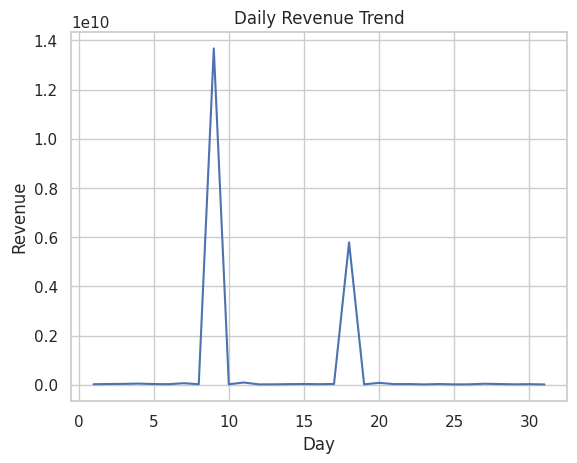

In [24]:

daily_revenue = df.groupby('Day')['revenue'].sum()

plt.figure()
daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

###monthly_pattern

In [26]:
monthly_pattern = df.groupby('Month')['revenue'].mean()
monthly_pattern


,revenue
Month,
1,276955.136029
2,2531.108496
3,1737.077689
4,3169.204522
5,2292.720465
6,2101.733339
7,1732.789598
8,2637.366253
9,2867.055874


### weekly_pattern

In [27]:
weekly_pattern = df.groupby('Day')['revenue'].mean()

# reorder properly
weekly_pattern = weekly_pattern.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
weekly_pattern

,revenue
Day,
Monday,NaN
Tuesday,NaN
Wednesday,NaN
Thursday,NaN
Friday,NaN
Saturday,NaN
Sunday,NaN


### Monthly Seasonality

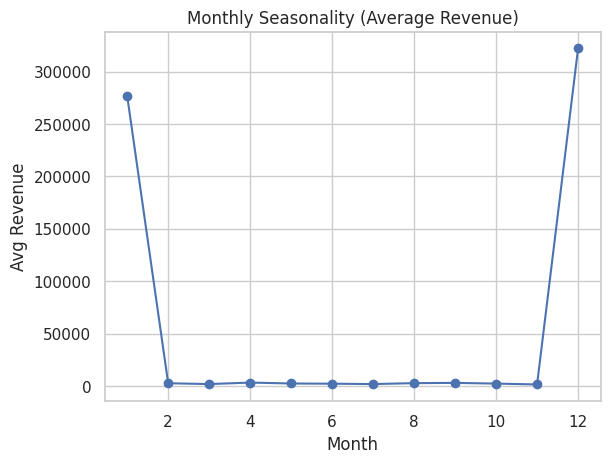

In [28]:
plt.figure()
monthly_pattern.plot(marker='o')
plt.title("Monthly Seasonality (Average Revenue)")
plt.xlabel("Month")
plt.ylabel("Avg Revenue")
plt.show()

### Weekly Seasonality

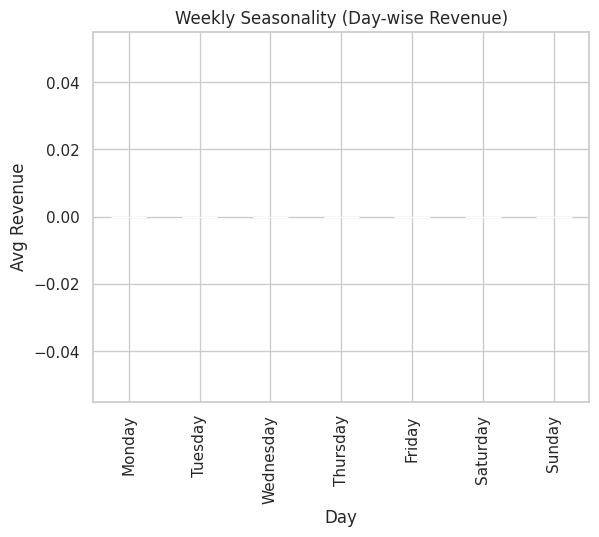

In [29]:
plt.figure()
weekly_pattern.plot(kind='bar')
plt.title("Weekly Seasonality (Day-wise Revenue)")
plt.xlabel("Day")
plt.ylabel("Avg Revenue")
plt.show()

In [30]:
top_days = df.sort_values(by='revenue', ascending=False).head(10)
print(top_days)

       InvoiceNo StockCode                          Description  Quantity  \
540421    581483     23843          PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
52711     540815     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
160546    550461     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
206121    554868     22197                 SMALL POPCORN HOLDER      4300   
97432     544612     22053                EMPIRE DESIGN ROSETTE      3906   
291249    562439     84879        ASSORTED COLOUR BIRD ORNAMENT      2880   
421601    573003     23084                   RABBIT NIGHT LIGHT      2400   
348325    567423     23243  SET OF TEA COFFEE SUGAR TINS PANTRY      1412   
52709     540815    85123A   WHITE HANGING HEART T-LIGHT HOLDER      1930   

               InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
540421 2011-12-09 09:15:00       2.08     16446.0  United Kingdom   168

### peak_month

In [31]:
peak_month = monthly_pattern.idxmax()
print("Peak Month:", peak_month)

Peak Month: 12


### peak_day

In [32]:
peak_day = weekly_pattern.idxmax()
print("Best Day of Week:", peak_day)

Best Day of Week: nan


/tmp/ipykernel_7542/1049752567.py:1: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  peak_day = weekly_pattern.idxmax()


### Converting to Datetime and Extracting Hour Feature

In [33]:
df['Day'] = pd.to_datetime(df['Day'])

df['hour'] = df['Day'].dt.hour

### hourly_pattern

In [34]:
hourly_pattern = df.groupby('hour')['revenue'].mean()
hourly_pattern

,revenue
hour,
0,51644.278324


### hourly_count

In [35]:
hourly_count = df.groupby('hour')['revenue'].count()
hourly_count

,revenue
hour,
0,392692


### Average Revenue by Hour

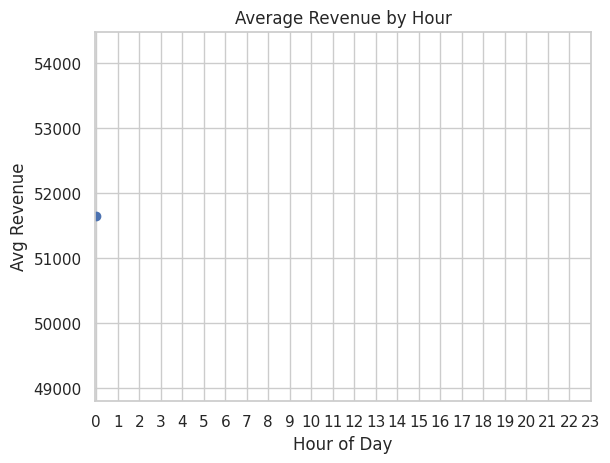

In [36]:
plt.figure()
hourly_pattern.plot(marker='o')
plt.title("Average Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Revenue")
plt.xticks(range(0,24))
plt.show()

### Number of Transactions by Hour

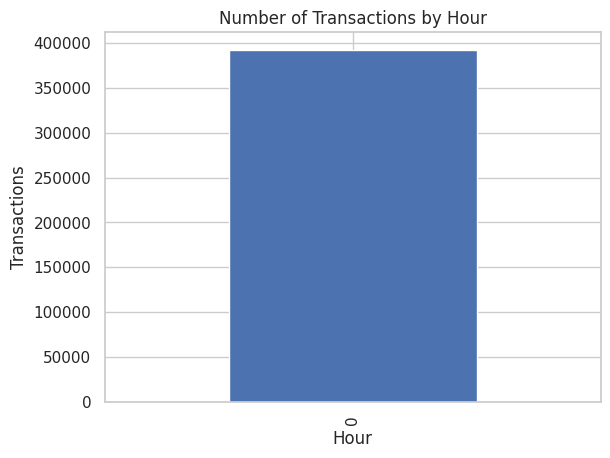

In [37]:
plt.figure()
hourly_count.plot(kind='bar')
plt.title("Number of Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

### peak_hour

In [38]:
peak_hour = hourly_pattern.idxmax()
print("Peak Revenue Hour:", peak_hour)

Peak Revenue Hour: 0


### Peak traffic

In [39]:
peak_traffic = hourly_count.idxmax()
print("Peak Transaction Hour:", peak_traffic)

Peak Transaction Hour: 0


### Ensuring Valid Sales Data (Quantity > 0, Unit Price > 0)

In [40]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

### Descriptive Statistics for Quantity and Unit Price

In [41]:
print(df[['Quantity', 'UnitPrice']].describe())

            Quantity      UnitPrice
count  392692.000000  392692.000000
mean       13.119702       3.125914
std       180.492832      22.241836
min         1.000000       0.001000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000


### Distribution of Order Quantity

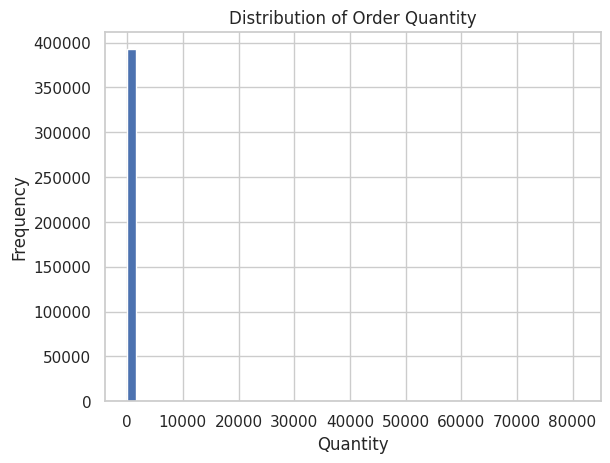

In [42]:
plt.figure()
df['Quantity'].plot(kind='hist', bins=50)
plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

### Boxplot of Order Quantity

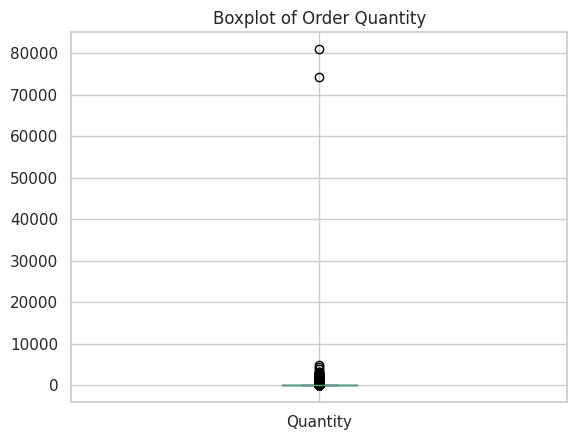

In [43]:
plt.figure()
df['Quantity'].plot(kind='box')
plt.title("Boxplot of Order Quantity")
plt.show()

### Distribution of Unit Price

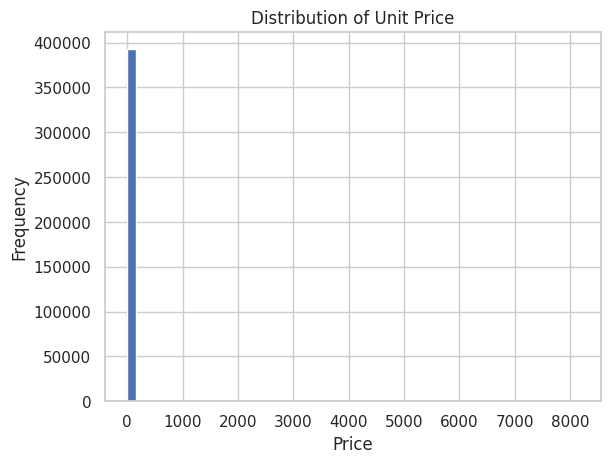

In [44]:
plt.figure()
df['UnitPrice'].plot(kind='hist', bins=50)
plt.title("Distribution of Unit Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Boxplot of Unit Price

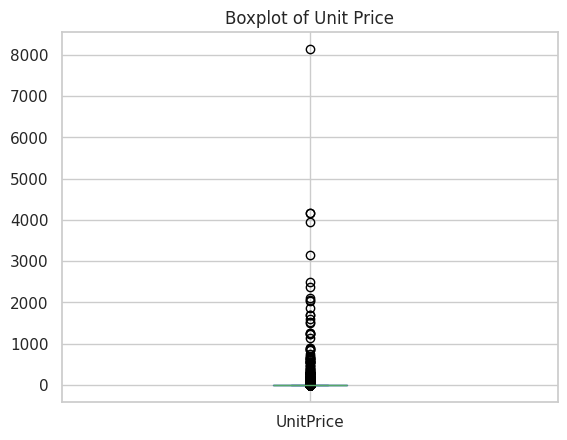

In [45]:
plt.figure()
df['UnitPrice'].plot(kind='box')
plt.title("Boxplot of Unit Price")
plt.show()

### Quantity vs Unit Price

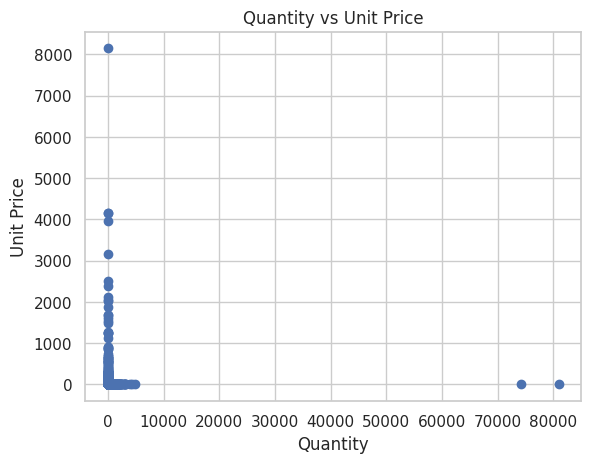

In [46]:
plt.figure()
plt.scatter(df['Quantity'], df['UnitPrice'])
plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()

### Calculating Order Value from Quantity and Unit Price

In [47]:
df['order_value'] = df['Quantity'] * df['UnitPrice']
df['order_value']

,order_value
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34
...,...
541904,10.20
541905,12.60
541906,16.60
541907,16.60


### Aggregating Customer-Level Order Value and First Purchase Date

In [48]:
order_df = df.groupby('CustomerID').agg({
    'order_value': 'sum',
    'Day': 'first'
}).reset_index()
order_df

,CustomerID,order_value,Day
0,12346.0,77183.60,1970-01-01 00:00:00.000000018
1,12347.0,4310.00,1970-01-01 00:00:00.000000007
2,12348.0,1797.24,1970-01-01 00:00:00.000000016
3,12349.0,1757.55,1970-01-01 00:00:00.000000021
4,12350.0,334.40,1970-01-01 00:00:00.000000002
...,...,...,...
4333,18280.0,180.60,1970-01-01 00:00:00.000000007
4334,18281.0,80.82,1970-01-01 00:00:00.000000012
4335,18282.0,178.05,1970-01-01 00:00:00.000000005
4336,18283.0,2045.53,1970-01-01 00:00:00.000000006


### Calculating Daily Average Order Value (AOV)

In [49]:
daily_aov = order_df.groupby('Day')['order_value'].mean()
daily_aov

,order_value
Day,
1970-01-01 00:00:00.000000001,4700.282644
1970-01-01 00:00:00.000000002,2185.039444
1970-01-01 00:00:00.000000003,3701.328639
1970-01-01 00:00:00.000000004,1090.520787
1970-01-01 00:00:00.000000005,2487.119096
1970-01-01 00:00:00.000000006,2152.406373
1970-01-01 00:00:00.000000007,4019.508214
1970-01-01 00:00:00.000000008,2171.705736
1970-01-01 00:00:00.000000009,1863.450546


### Calculating weekly Average Order Value (AOV)


In [50]:
weekly_aov = order_df.groupby(order_df['Day'].dt.to_period('W'))['order_value'].mean()
weekly_aov.index = weekly_aov.index.to_timestamp()
weekly_aov

,order_value
Day,
1969-12-29,2048.688081


### Calculating monthly Average Order Value (AOV)


In [51]:
monthly_aov = order_df.groupby(order_df['Day'].dt.to_period('M'))['order_value'].mean()
monthly_aov.index = monthly_aov.index.to_timestamp()
monthly_aov

,order_value
Day,
1970-01-01,2048.688081


### Visualizing Daily Average Order Value (AOV) Trend

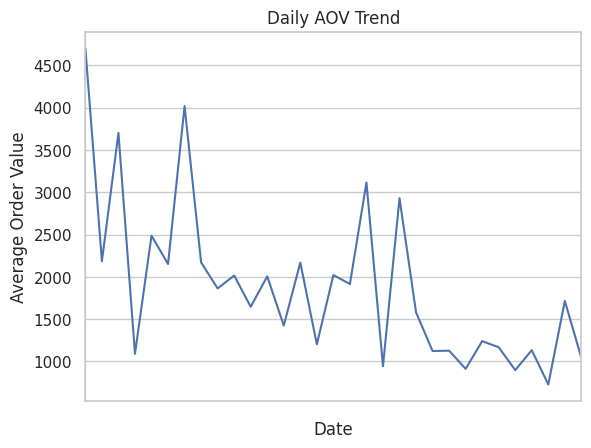

In [52]:
plt.figure()
daily_aov.plot()
plt.title("Daily AOV Trend")
plt.xlabel("Date")
plt.ylabel("Average Order Value")
plt.show()

### Visualizing Weekly Average Order Value (AOV) Trend


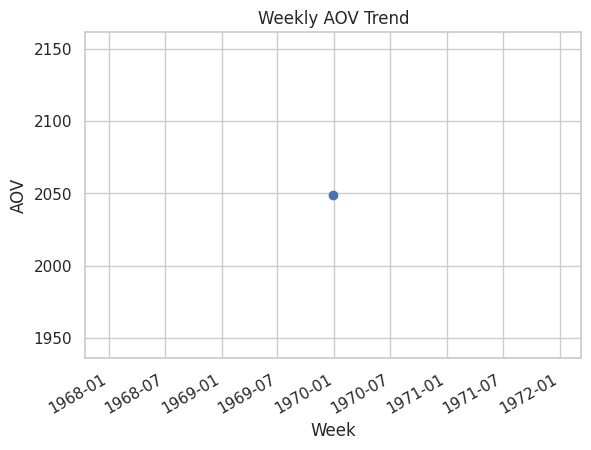

In [53]:
plt.figure()
weekly_aov.plot(marker='o')
plt.title("Weekly AOV Trend")
plt.xlabel("Week")
plt.ylabel("AOV")
plt.show()

### Visualizing Monthly Average Order Value (AOV) Trend


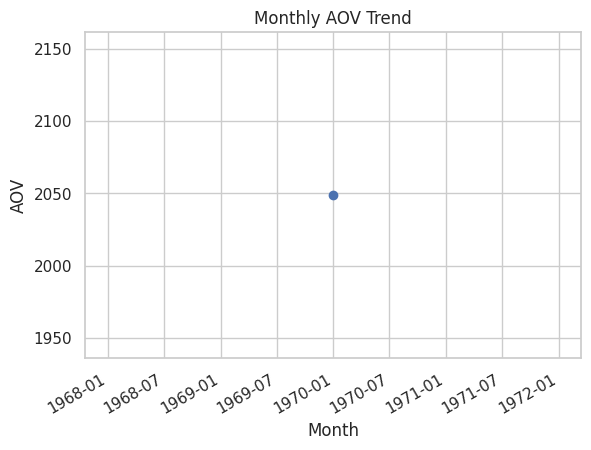

In [54]:
plt.figure()
monthly_aov.plot(marker='o')
plt.title("Monthly AOV Trend")
plt.xlabel("Month")
plt.ylabel("AOV")
plt.show()

### Visual Analysis of Daily Revenue and AOV

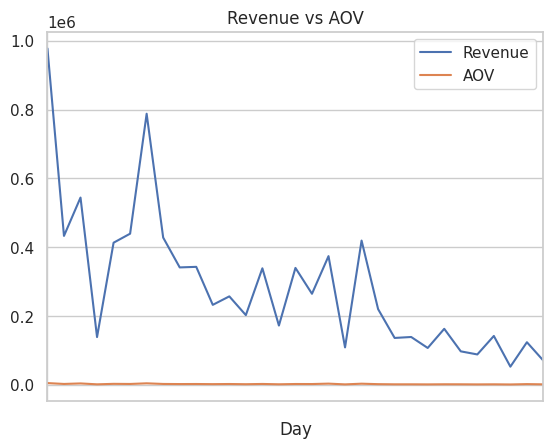

In [55]:
daily_revenue = order_df.groupby('Day')['order_value'].sum()

plt.figure()
daily_revenue.plot(label='Revenue')
daily_aov.plot(label='AOV')
plt.legend()
plt.title("Revenue vs AOV")
plt.show()

### Creating Customer Basket Dataset with Total Items and Revenue

In [56]:
df['Day'] = pd.to_datetime(df['Day'])

basket_df = df.groupby('CustomerID').agg({
    'Quantity': 'sum',     # total items in order
    'revenue': 'sum',      # total order value
    'Day': 'first'
}).reset_index()

basket_df.rename(columns={'Quantity': 'basket_size'}, inplace=True)
basket_df

,CustomerID,basket_size,revenue,Day
0,12346.0,74215,5.728181e+09,1970-01-01 00:00:00.000000018
1,12347.0,2458,1.166280e+05,1970-01-01 00:00:00.000000007
2,12348.0,2341,1.394712e+05,1970-01-01 00:00:00.000000016
3,12349.0,631,1.403511e+04,1970-01-01 00:00:00.000000021
4,12350.0,197,3.694400e+03,1970-01-01 00:00:00.000000002
...,...,...,...,...
4333,18280.0,45,8.220000e+02,1970-01-01 00:00:00.000000007
4334,18281.0,54,4.721400e+02,1970-01-01 00:00:00.000000012
4335,18282.0,103,1.422610e+03,1970-01-01 00:00:00.000000005
4336,18283.0,1357,5.862930e+03,1970-01-01 00:00:00.000000006


### Extracting Day, Hour, and Month Features from Datetime

In [57]:
basket_df['day_name'] = basket_df['Day'].dt.day_name()
basket_df['hour'] = basket_df['Day'].dt.hour
basket_df['month'] = basket_df['Day'].dt.month

### Analyzing Basket Size Distribution

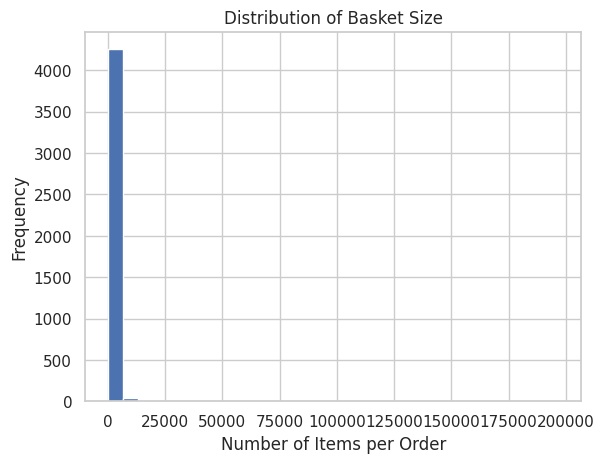

In [58]:
plt.figure()
basket_df['basket_size'].plot(kind='hist', bins=30)
plt.title("Distribution of Basket Size")
plt.xlabel("Number of Items per Order")
plt.ylabel("Frequency")
plt.show()

### Basket Size Boxplot

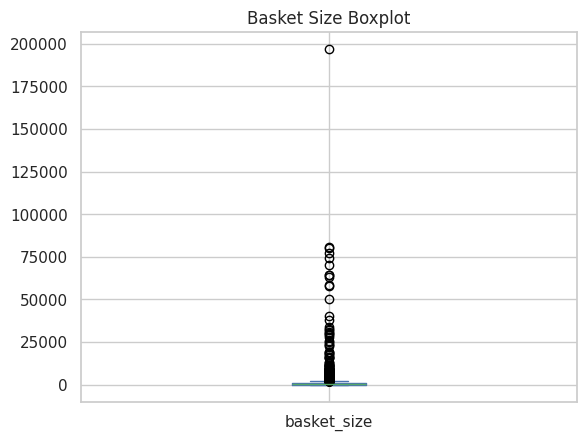

In [59]:
plt.figure()
basket_df['basket_size'].plot(kind='box')
plt.title("Basket Size Boxplot")
plt.show()

### Visualizing Average Basket Size Over Time

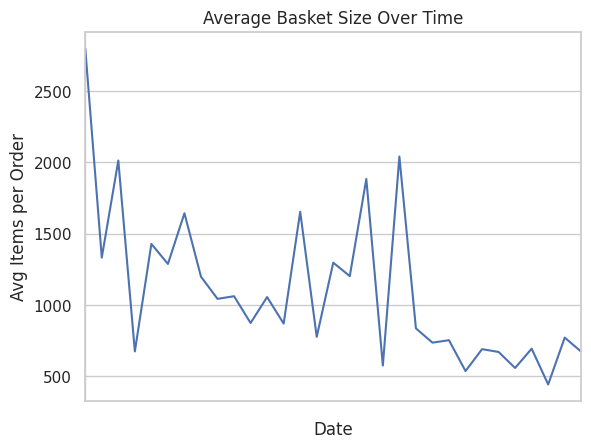

In [60]:
daily_basket = basket_df.groupby('Day')['basket_size'].mean()

plt.figure()
daily_basket.plot()
plt.title("Average Basket Size Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Items per Order")
plt.show()

### Average Basket Size by Day of the Week

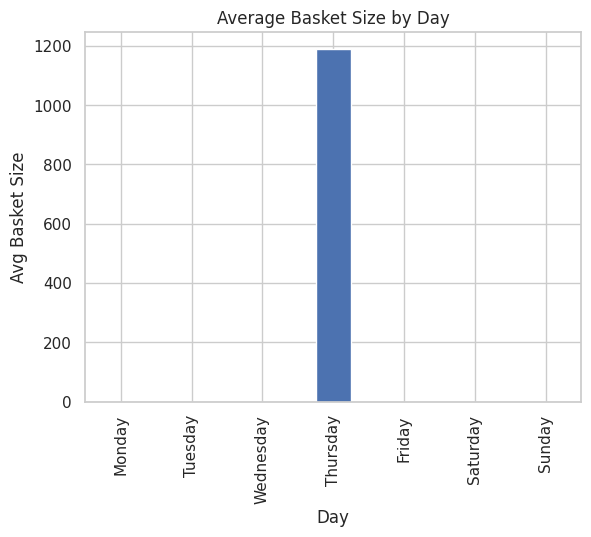

In [61]:
day_pattern = basket_df.groupby('day_name')['basket_size'].mean()

day_pattern = day_pattern.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure()
day_pattern.plot(kind='bar')
plt.title("Average Basket Size by Day")
plt.xlabel("Day")
plt.ylabel("Avg Basket Size")
plt.show()

### Average Basket Size by Hour of the Day

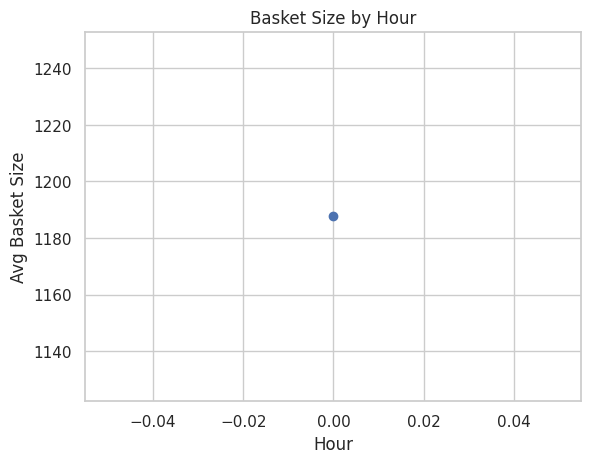

In [62]:
hour_pattern = basket_df.groupby('hour')['basket_size'].mean()

plt.figure()
hour_pattern.plot(marker='o')
plt.title("Basket Size by Hour")
plt.xlabel("Hour")
plt.ylabel("Avg Basket Size")
plt.show()

### Relationship Between Basket Size and Order Value

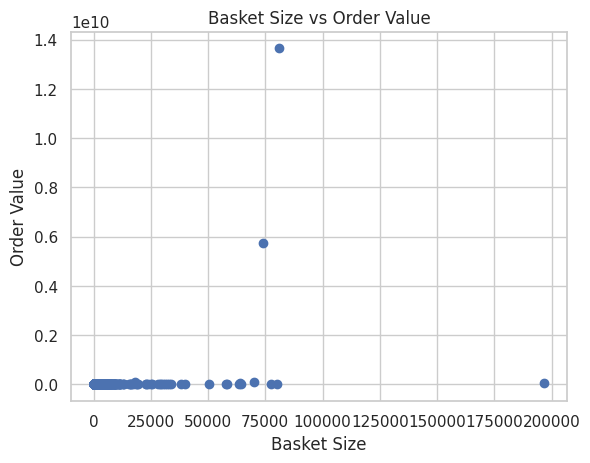

In [63]:
plt.figure()
plt.scatter(basket_df['basket_size'], basket_df['revenue'])
plt.title("Basket Size vs Order Value")
plt.xlabel("Basket Size")
plt.ylabel("Order Value")
plt.show()

### Product-Level Summary: Total Quantity and Revenue

In [64]:
product_summary = df.groupby('Description').agg({
    'Quantity': 'sum',
    'revenue': 'sum'
}).reset_index()
product_summary

,Description,Quantity,revenue
0,4 PURPLE FLOCK DINNER CANDLES,138,1748.68
1,50'S CHRISTMAS GIFT BAG LARGE,1885,199691.25
2,DOLLY GIRL BEAKER,2394,491420.00
3,I LOVE LONDON MINI BACKPACK,359,29585.65
4,I LOVE LONDON MINI RUCKSACK,1,4.15
...,...,...,...
3872,ZINC T-LIGHT HOLDER STARS SMALL,4894,237812.24
3873,ZINC TOP 2 DOOR WOODEN SHELF,10,203.40
3874,ZINC WILLIE WINKIE CANDLE STICK,2606,71953.92
3875,ZINC WIRE KITCHEN ORGANISER,25,390.10


### Top 10 Products by Quantity Sold

In [65]:
top_qty = product_summary.sort_values(by='Quantity', ascending=False).head(10)
top_qty

,Description,Quantity,revenue
2319,"PAPER CRAFT , LITTLE BIRDIE",80995,1.364520e+10
1992,MEDIUM CERAMIC TOP STORAGE JAR,77916,5.728497e+09
3786,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,1.170728e+07
1762,JUMBO BAG RED RETROSPOT,46078,1.487663e+07
3698,WHITE HANGING HEART T-LIGHT HOLDER,36706,3.304777e+07
216,ASSORTED COLOUR BIRD ORNAMENT,35263,1.850847e+07
2269,PACK OF 72 RETROSPOT CAKE CASES,33670,4.146204e+06
2600,POPCORN HOLDER,30919,1.282992e+07
2656,RABBIT NIGHT LIGHT,27153,3.138151e+07
2047,MINI PAINT SET VINTAGE,26076,5.610382e+06


### Top 10 Products by Revenue

In [66]:
top_rev = product_summary.sort_values(by='revenue', ascending=False).head(10)
top_rev

,Description,Quantity,revenue
2319,"PAPER CRAFT , LITTLE BIRDIE",80995,1.364520e+10
1992,MEDIUM CERAMIC TOP STORAGE JAR,77916,5.728497e+09
1160,FAIRY CAKE FLANNEL ASSORTED COLOUR,10070,4.106362e+07
3698,WHITE HANGING HEART T-LIGHT HOLDER,36706,3.304777e+07
2656,RABBIT NIGHT LIGHT,27153,3.138151e+07
216,ASSORTED COLOUR BIRD ORNAMENT,35263,1.850847e+07
3270,SMALL POPCORN HOLDER,18241,1.529344e+07
1387,GIN + TONIC DIET METAL SIGN,11501,1.504946e+07
1528,GROW A FLYTRAP OR SUNFLOWER IN TIN,15940,1.493035e+07
1762,JUMBO BAG RED RETROSPOT,46078,1.487663e+07


### Horizontal Bar Chart of Top 10 Products by Quantity Sold

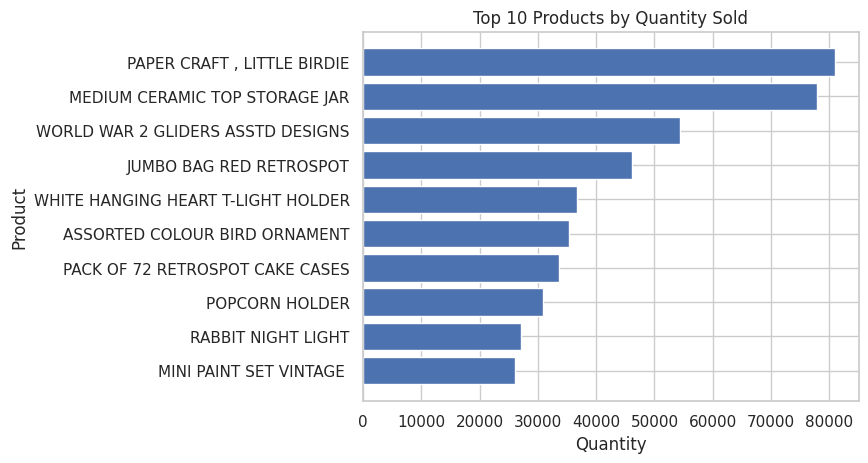

In [67]:
plt.figure()
plt.barh(top_qty['Description'], top_qty['Quantity'])
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

### Horizontal Bar Chart of Top 10 Products by Revenue

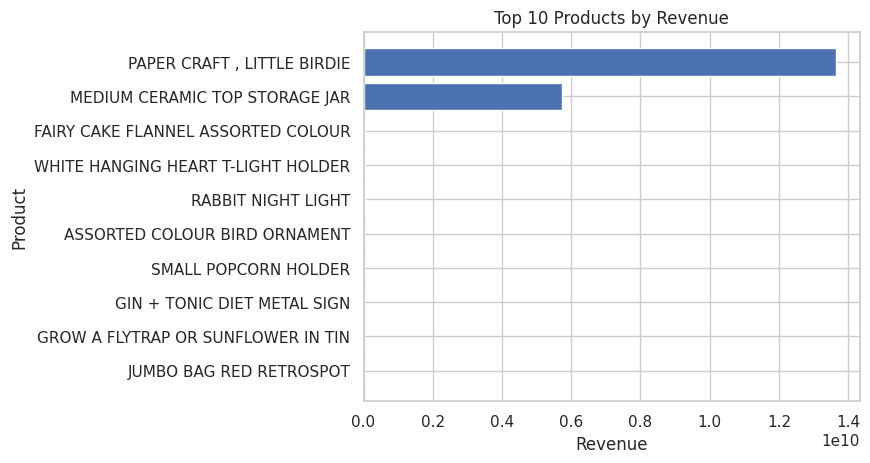

In [68]:
plt.figure()
plt.barh(top_rev['Description'], top_rev['revenue'])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

### Relationship Between Quantity Sold and Revenue by Product

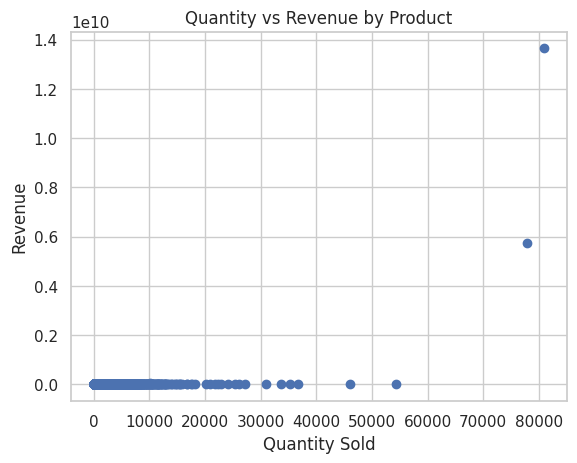

In [69]:
plt.figure()
plt.scatter(product_summary['Quantity'], product_summary['revenue'])
plt.title("Quantity vs Revenue by Product")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")
plt.show()

### Product-Level Summary: Quantity, Revenue, and Unique Customers

In [70]:
product_summary = df.groupby('Description').agg({
    'Quantity': 'sum',
    'revenue': 'sum',
    'CustomerID': 'nunique'
}).reset_index()

product_summary.rename(columns={'order_id': 'num_orders'}, inplace=True)
product_summary

,Description,Quantity,revenue,CustomerID
0,4 PURPLE FLOCK DINNER CANDLES,138,1748.68,31
1,50'S CHRISTMAS GIFT BAG LARGE,1885,199691.25,106
2,DOLLY GIRL BEAKER,2394,491420.00,100
3,I LOVE LONDON MINI BACKPACK,359,29585.65,58
4,I LOVE LONDON MINI RUCKSACK,1,4.15,1
...,...,...,...,...
3872,ZINC T-LIGHT HOLDER STARS SMALL,4894,237812.24,180
3873,ZINC TOP 2 DOOR WOODEN SHELF,10,203.40,9
3874,ZINC WILLIE WINKIE CANDLE STICK,2606,71953.92,137
3875,ZINC WIRE KITCHEN ORGANISER,25,390.10,12


### Deriving Average Price and Average Order Quantity per Product

In [71]:
product_summary['avg_price'] = product_summary['revenue'] / product_summary['Quantity']
product_summary['avg_order_qty'] = product_summary['Quantity'] / product_summary['CustomerID']
product_summary

,Description,Quantity,revenue,CustomerID,avg_price,avg_order_qty
0,4 PURPLE FLOCK DINNER CANDLES,138,1748.68,31,12.671594,4.451613
1,50'S CHRISTMAS GIFT BAG LARGE,1885,199691.25,106,105.937003,17.783019
2,DOLLY GIRL BEAKER,2394,491420.00,100,205.271512,23.940000
3,I LOVE LONDON MINI BACKPACK,359,29585.65,58,82.411281,6.189655
4,I LOVE LONDON MINI RUCKSACK,1,4.15,1,4.150000,1.000000
...,...,...,...,...,...,...
3872,ZINC T-LIGHT HOLDER STARS SMALL,4894,237812.24,180,48.592611,27.188889
3873,ZINC TOP 2 DOOR WOODEN SHELF,10,203.40,9,20.340000,1.111111
3874,ZINC WILLIE WINKIE CANDLE STICK,2606,71953.92,137,27.610867,19.021898
3875,ZINC WIRE KITCHEN ORGANISER,25,390.10,12,15.604000,2.083333


### Underperforming Product Analysis Based on Quantiles

In [72]:
rev_threshold = product_summary['revenue'].quantile(0.2)
qty_threshold = product_summary['Quantity'].quantile(0.2)

underperforming = product_summary[
    (product_summary['revenue'] <= rev_threshold) &
    (product_summary['Quantity'] <= qty_threshold)
]
underperforming

,Description,Quantity,revenue,CustomerID,avg_price,avg_order_qty
4,I LOVE LONDON MINI RUCKSACK,1,4.15,1,4.150,1.000000
10,TOADSTOOL BEDSIDE LIGHT,2,35.80,1,17.900,2.000000
29,15 PINK FLUFFY CHICKS IN BOX,10,47.20,7,4.720,1.428571
31,16 PC CUTLERY SET PANTRY DESIGN,4,255.20,1,63.800,4.000000
34,2 DAISIES HAIR COMB,6,106.20,1,17.700,6.000000
...,...,...,...,...,...,...
3866,ZINC PLANT POT HOLDER,8,184.96,1,23.120,8.000000
3867,ZINC STAR T-LIGHT HOLDER,8,80.00,1,10.000,8.000000
3871,ZINC T-LIGHT HOLDER STARS LARGE,24,273.60,2,11.400,12.000000
3873,ZINC TOP 2 DOOR WOODEN SHELF,10,203.40,9,20.340,1.111111


### Visualizing Bottom 10 Products by Revenue

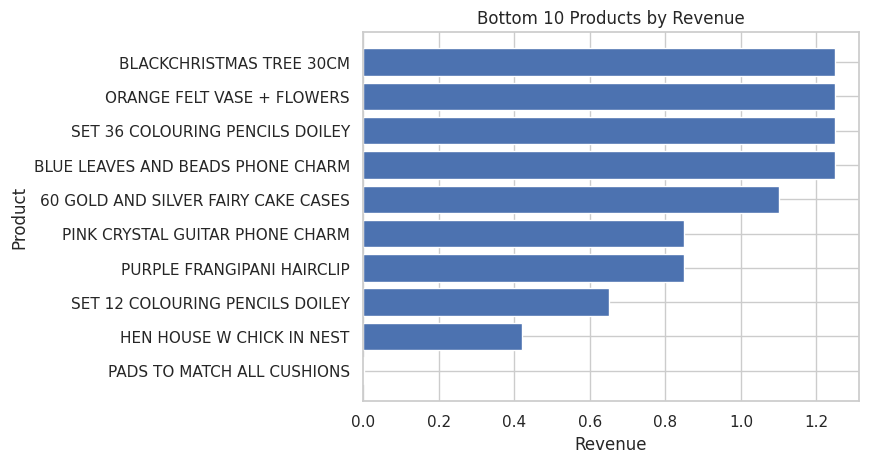

In [73]:
bottom_rev = product_summary.sort_values(by='revenue').head(10)

plt.figure()
plt.barh(bottom_rev['Description'], bottom_rev['revenue'])
plt.title("Bottom 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

### Lowest Performing Products by Quantity

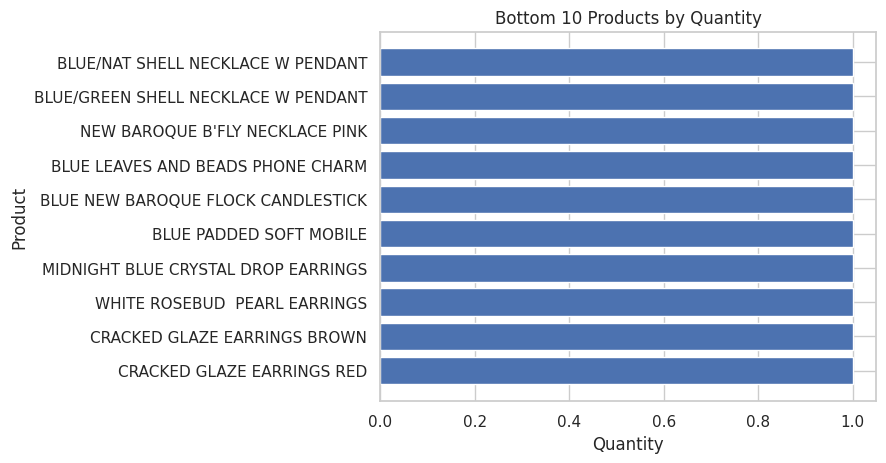

In [74]:
bottom_qty = product_summary.sort_values(by='Quantity').head(10)

plt.figure()
plt.barh(bottom_qty['Description'], bottom_qty['Quantity'])
plt.title("Bottom 10 Products by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.show()

### Product Performance: Quantity vs Revenue

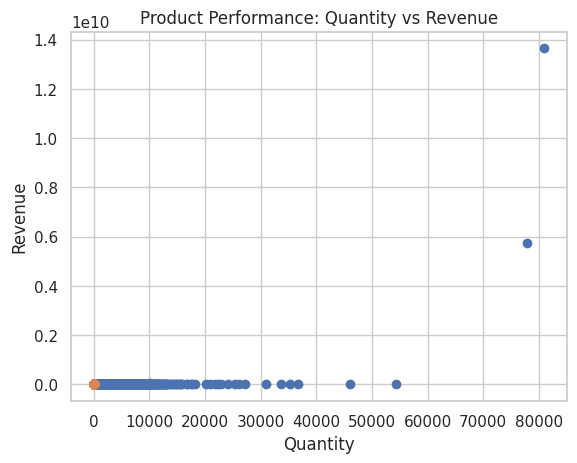

In [75]:
plt.figure()
plt.scatter(product_summary['Quantity'], product_summary['revenue'])

# highlight underperformers
plt.scatter(
    underperforming['Quantity'],
    underperforming['revenue']
)

plt.title("Product Performance: Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

### Calculating Customer Purchase Frequency (Number of Unique Orders)

In [76]:
cus_freq = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cus_freq.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)

cus_freq.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


### Customer Purchase Frequency Distribution

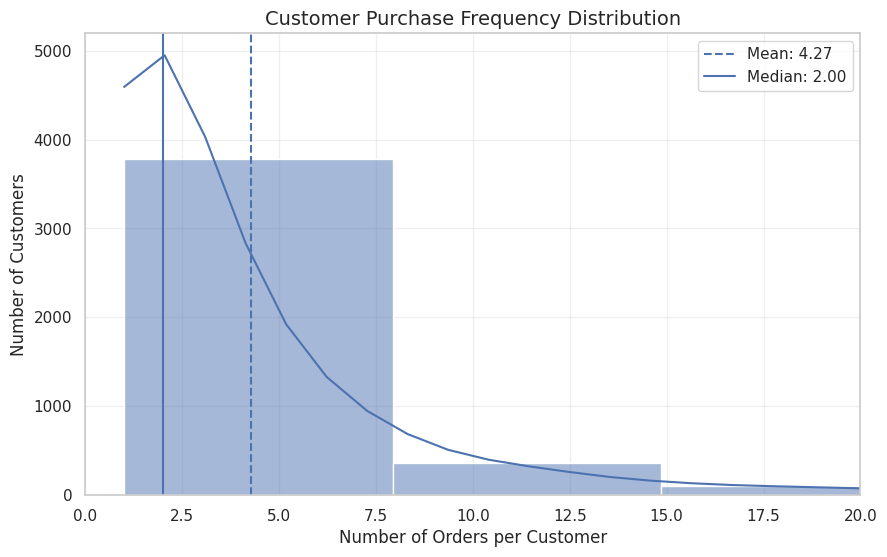

In [77]:
plt.figure(figsize=(10,6))

sns.histplot(
    cus_freq['Frequency'],
    bins=30,
    kde=True   # smooth distribution curve
)

plt.title("Customer Purchase Frequency Distribution", fontsize=14)
plt.xlabel("Number of Orders per Customer", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xlim(0, 20)

# Add mean & median lines
mean_val = cus_freq['Frequency'].mean()
median_val = cus_freq['Frequency'].median()

plt.axvline(mean_val, linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, linestyle='-', label=f'Median: {median_val:.2f}')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Analyzing Repeat vs One-Time Customer Distribution

In [78]:
total_customers = len(cus_freq)

repeat_cus = (cus_freq['Frequency'] > 1).sum()
one_time_cus = (cus_freq['Frequency'] == 1).sum()

repeat_pct = (repeat_cus / total_customers) * 100
one_time_pct = (one_time_cus / total_customers) * 100

print(f"Repeat Customers: {repeat_cus} ({repeat_pct:.2f}%)")
print(f"One-time Customers: {one_time_cus} ({one_time_pct:.2f}%)")

Repeat Customers: 2845 (65.58%)
One-time Customers: 1493 (34.42%)


### Customer Purchase Behaviour

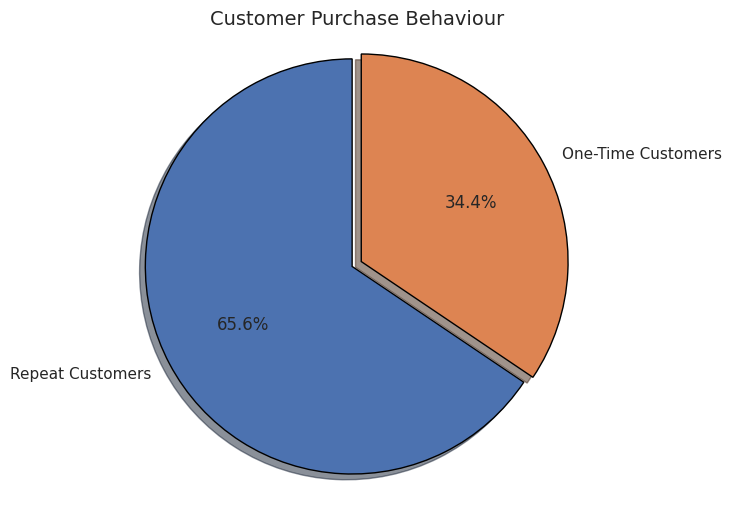

In [79]:
plt.figure(figsize=(6,6))

values = [repeat_cus, one_time_cus]
labels = ['Repeat Customers', 'One-Time Customers']

explode = (0.05, 0)  # highlight repeat customers

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Customer Purchase Behaviour", fontsize=14)
plt.axis('equal')  # ensures perfect circle

plt.show()

### Top 10 Countries by Total Sales Revenue

In [80]:
country_sales = (
    df.groupby('Country')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

country_sales

,Country,TotalPrice
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


### Visualizing Top 10 Countries by Revenue

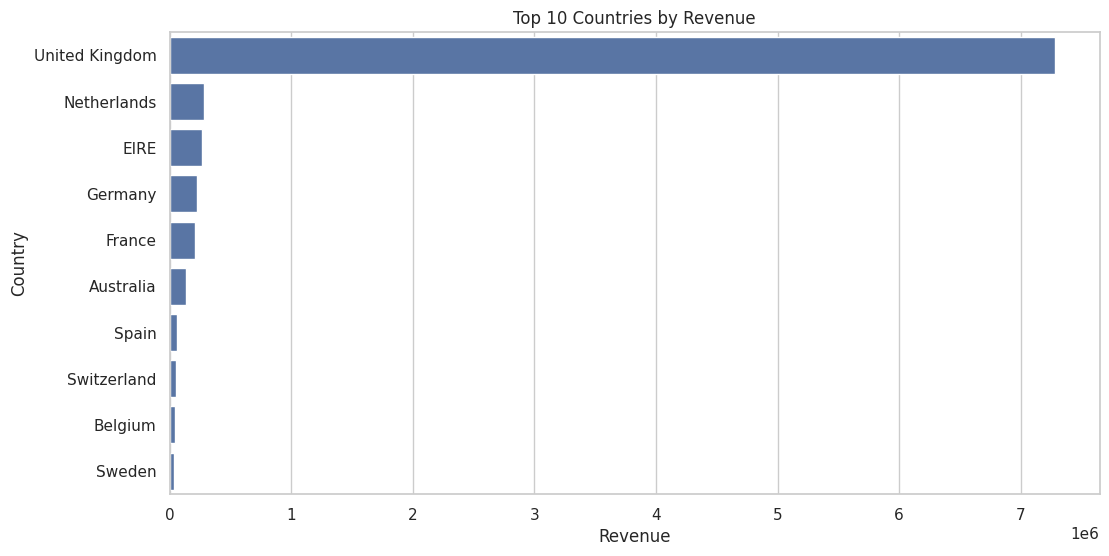

In [81]:
country_sales.rename(columns={'TotalPrice': 'Revenue'}, inplace=True)

plt.figure(figsize=(12,6))

sns.barplot(data=country_sales, y='Country', x='Revenue')

plt.title("Top 10 Countries by Revenue")
plt.show()

### Creating CSV file for cleaned data

In [83]:
df.to_csv("cleaned_data.csv", index=False)

# **Phase 4: Customer Segmentation (RFM Analysis)**

## **Methodology**

In this phase, we use the **RFM (Recency, Frequency, Monetary)** framework to segment customers based on their purchasing behavior. This helps in identifying valuable customers as well as those who may be at risk of churn.



## **1. RFM Feature Construction**

We calculate the following three key metrics for each customer:

- **Recency:** Measures how recently a customer made a purchase (lower value indicates more recent activity).
- **Frequency:** Represents the total number of transactions made by each customer (higher value indicates stronger engagement).
- **Monetary:** Total spending amount contributed by each customer (higher value indicates higher value customers).



## **2. RFM Scoring & Customer Segmentation**

Each RFM metric is converted into a score (typically on a scale of 1 to 5) using quantile-based segmentation. These scores are then combined to form an overall customer profile.

Based on the combined RFM scores, customers are grouped into segments such as:

- **VIP / High-Value Customers**
- **Loyal Customers**
- **At-Risk Customers**
- **Churned / Lost Customers**



## **3. Business Interpretation**

This segmentation enables actionable insights such as:

- Identifying high-value customers who contribute the most revenue.
- Detecting customers who previously spent more but have reduced recent activity (potential churn risk).
- Supporting targeted marketing campaigns and retention strategies.


## **4. Additional Analytical Insights**

### **Correlation Analysis**
- Examine relationships between important variables such as:
  - Frequency vs Monetary value
  - Quantity vs Unit Price  
- Helps understand customer purchasing behavior patterns.

### **Outlier Detection**
- Apply the IQR method to detect extreme values in purchase quantity and spending.
- Identify potential wholesale or bulk buyers whose behavior differs significantly from regular customers.
- Use this step to refine analysis and reduce distortion in results.


### Converting Invoice Date Column to Datetime Format

In [84]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### Creating Reference Date for Customer Recency Calculation

In [85]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

### Calculating RFM Features for Customer Segmentation

In [86]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'revenue': 'sum'                                          # Monetary
}).reset_index()
rfm

,CustomerID,InvoiceDate,InvoiceNo,revenue
0,12346.0,326,1,5.728181e+09
1,12347.0,2,7,1.166280e+05
2,12348.0,75,4,1.394712e+05
3,12349.0,19,1,1.403511e+04
4,12350.0,310,1,3.694400e+03
...,...,...,...,...
4333,18280.0,278,1,8.220000e+02
4334,18281.0,181,1,4.721400e+02
4335,18282.0,8,2,1.422610e+03
4336,18283.0,4,16,5.862930e+03


### Renaming Columns for RFM Metrics

In [87]:
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

### Recency Distribution

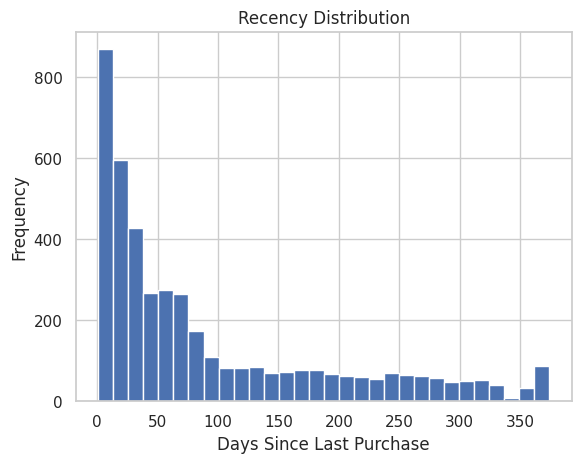

In [88]:
plt.figure()
rfm['Recency'].plot(kind='hist', bins=30)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()

### Frequency Distribution

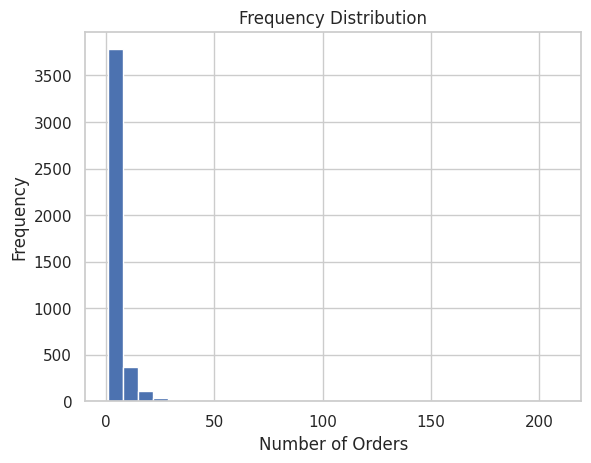

In [89]:
plt.figure()
rfm['Frequency'].plot(kind='hist', bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.show()

### Monetary Distribution

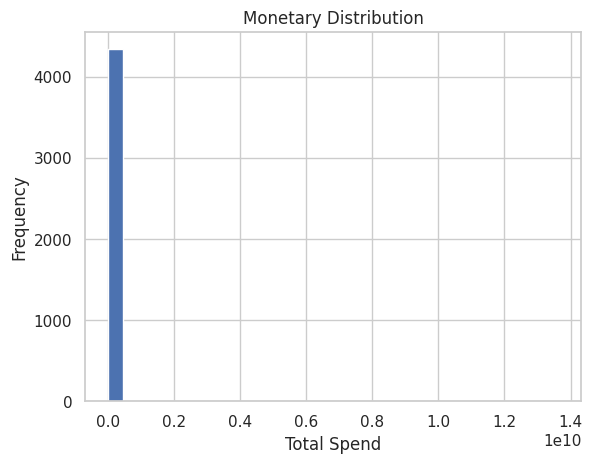

In [90]:
plt.figure()
rfm['Monetary'].plot(kind='hist', bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Total Spend")
plt.show()

### Frequency vs Monetary

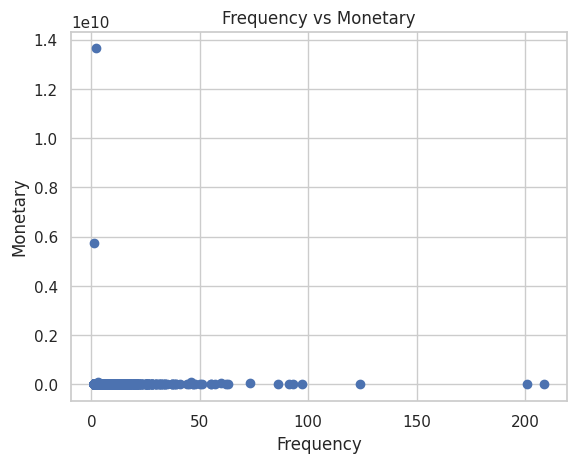

In [91]:
plt.figure()
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.title("Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

### Calculating RFM Scores Using Quartile-Based Segmentation

In [92]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

### Creating Combined RFM Score (RFM Segmentation Code)

In [93]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

### Top RFM Segments

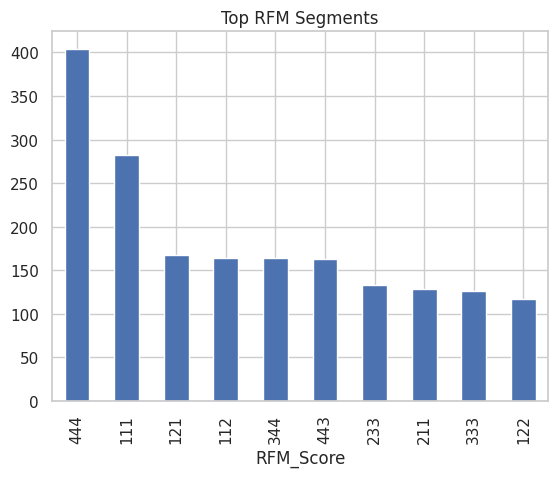

In [94]:
rfm['RFM_Score'].value_counts().head(10).plot(kind='bar')
plt.title("Top RFM Segments")
plt.show()

### Customer Segmentation: RFM Scoring with 5-Level Ranking

In [95]:
# Recency (LOW is better → reverse scoring)
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

# Frequency (HIGH is better)
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

# Monetary (HIGH is better)
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

### Creating Composite RFM Score from Individual R, F, and M Scores

In [96]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

### Customer Segmentation Based on RFM Scores

In [97]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP / High-Value'
    elif f >= 4:
        return 'Loyal'
    elif r <= 2 and f <= 2:
        return 'At-Risk'
    elif r == 1:
        return 'Lost'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

### Customer Segmentation (RFM)

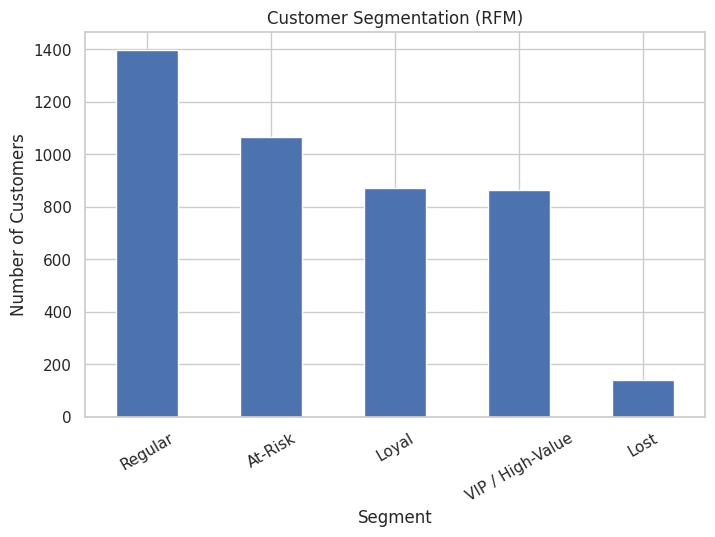

In [98]:
plt.figure(figsize=(8,5))

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segmentation (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

### Customer Segment Distribution

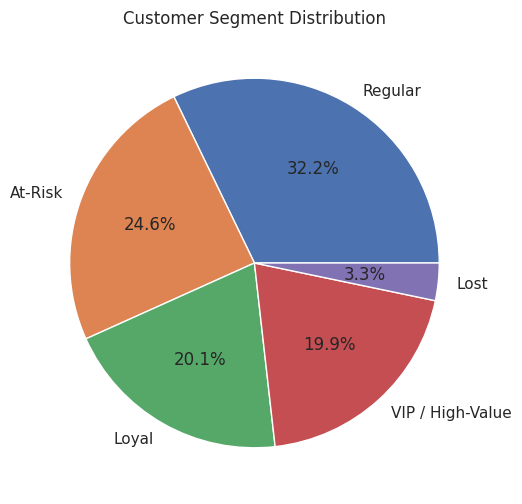

In [99]:
plt.figure(figsize=(6,6))

rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Customer Segment Distribution")
plt.ylabel('')

plt.show()

### Customer Segments (Frequency vs Monetary)

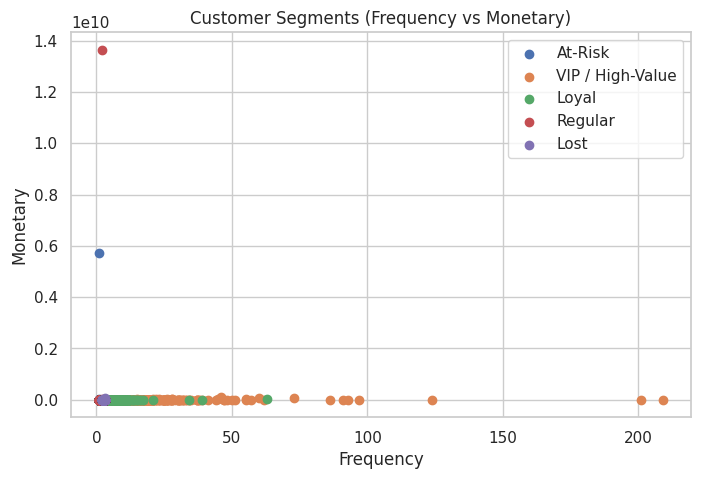

In [100]:
plt.figure(figsize=(8,5))

for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=segment)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments (Frequency vs Monetary)")
plt.legend()

plt.show()

### Overview of Customer Frequency and Monetary Metrics

In [101]:
rfm[['Frequency', 'Monetary']]

,Frequency,Monetary
0,1,5.728181e+09
1,7,1.166280e+05
2,4,1.394712e+05
3,1,1.403511e+04
4,1,3.694400e+03
...,...,...
4333,1,8.220000e+02
4334,1,4.721400e+02
4335,2,1.422610e+03
4336,16,5.862930e+03


### Overview of Quantity and Unit Price Data

In [102]:
df[['Quantity', 'UnitPrice']]

,Quantity,UnitPrice
0,6,2.55
1,6,3.39
2,8,2.75
3,6,3.39
4,6,3.39
...,...,...
541904,12,0.85
541905,6,2.10
541906,4,4.15
541907,4,4.15


### Correlation Analysis Between Frequency and Monetary Value

In [103]:
corr_fm = rfm[['Frequency', 'Monetary']].corr()
print(corr_fm)

           Frequency  Monetary
Frequency   1.000000 -0.003472
Monetary   -0.003472  1.000000


### Correlation Analysis Between Quantity and UnitPrice Value

In [104]:
corr_qp = df[['Quantity', 'UnitPrice']].corr()
print(corr_qp)

           Quantity  UnitPrice
Quantity   1.000000  -0.004578
UnitPrice -0.004578   1.000000


### Frequency vs Monetary

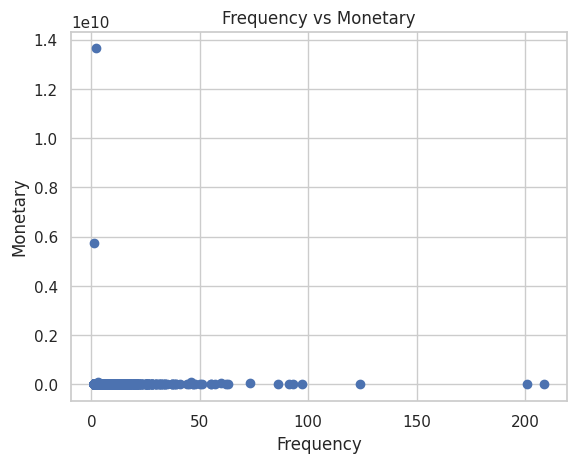

In [105]:
plt.figure()
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.title("Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

### Quantity vs Unit Price

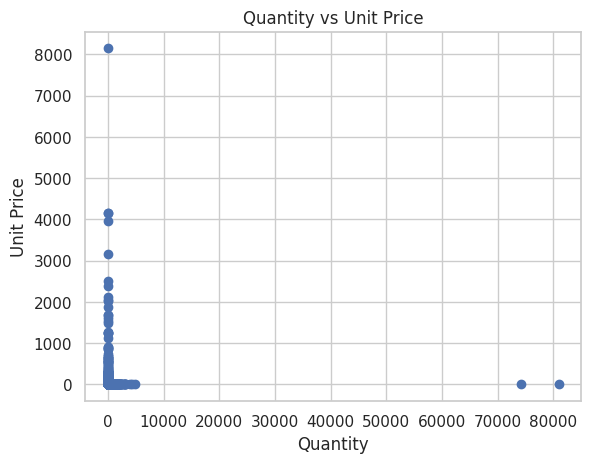

In [106]:
plt.figure()
plt.scatter(df['Quantity'], df['UnitPrice'])
plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()

### RFM Correlation Matrix

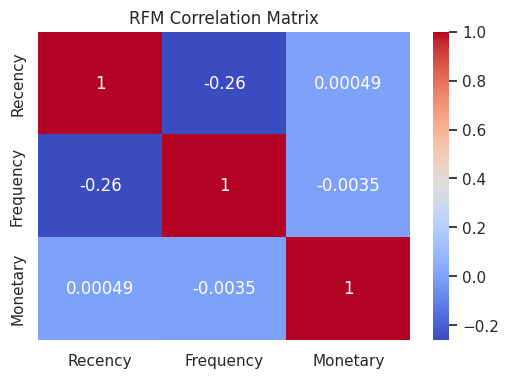

In [107]:
plt.figure(figsize=(6,4))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("RFM Correlation Matrix")
plt.show()

### Detecting Outliers in Quantity Using the IQR Method

In [108]:
Q1_q = df['Quantity'].quantile(0.25)
Q3_q = df['Quantity'].quantile(0.75)
IQR_q = Q3_q - Q1_q

lower_q = Q1_q - 1.5 * IQR_q
upper_q = Q3_q + 1.5 * IQR_q

quantity_outliers = df[(df['Quantity'] < lower_q) | (df['Quantity'] > upper_q)]
quantity_outliers

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,revenue,hour,order_value
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,1970-01-01 00:00:00.000000001,Wednesday,1730.56,0,54.08
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,2010,12,1970-01-01 00:00:00.000000001,Wednesday,1958.40,0,40.80
44,536370,22492,MINI PAINT SET VINTAGE,36,2010-12-01 08:45:00,0.65,12583.0,France,23.40,2010,12,1970-01-01 00:00:00.000000001,Wednesday,842.40,0,23.40
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,16320.00,0,204.00
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.40,2010,12,1970-01-01 00:00:00.000000001,Wednesday,11212.80,0,350.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541835,581579,23581,JUMBO BAG PAISLEY PARK,40,2011-12-09 12:19:00,1.79,17581.0,United Kingdom,71.60,2011,12,1970-01-01 00:00:00.000000009,Friday,2864.00,0,71.60
541865,581583,20725,LUNCH BAG RED RETROSPOT,40,2011-12-09 12:23:00,1.45,13777.0,United Kingdom,58.00,2011,12,1970-01-01 00:00:00.000000009,Friday,2320.00,0,58.00
541866,581583,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,36,2011-12-09 12:23:00,1.85,13777.0,United Kingdom,66.60,2011,12,1970-01-01 00:00:00.000000009,Friday,2397.60,0,66.60
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom,51.84,2011,12,1970-01-01 00:00:00.000000009,Friday,3732.48,0,51.84


### Filtering Extreme Revenue Values Using IQR

In [109]:
Q1_r = df['revenue'].quantile(0.25)
Q3_r = df['revenue'].quantile(0.75)
IQR_r = Q3_r - Q1_r

lower_r = Q1_r - 1.5 * IQR_r
upper_r = Q3_r + 1.5 * IQR_r

revenue_outliers = df[(df['revenue'] < lower_r) | (df['revenue'] > upper_r)]
revenue_outliers

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,revenue,hour,order_value
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,1970-01-01 00:00:00.000000001,Wednesday,1730.56,0,54.08
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,2160.00,0,90.00
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,2160.00,0,90.00
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,540.00,0,45.00
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,2010,12,1970-01-01 00:00:00.000000001,Wednesday,1958.40,0,40.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom,51.84,2011,12,1970-01-01 00:00:00.000000009,Friday,3732.48,0,51.84
541868,581584,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,48,2011-12-09 12:25:00,1.85,13777.0,United Kingdom,88.80,2011,12,1970-01-01 00:00:00.000000009,Friday,4262.40,0,88.80
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,30.00,2011,12,1970-01-01 00:00:00.000000009,Friday,720.00,0,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,214.80,2011,12,1970-01-01 00:00:00.000000009,Friday,5155.20,0,214.80


### Identifying High-Value Outliers in Quantity and Revenue

In [110]:
outliers = df[
    (df['Quantity'] > upper_q) |
    (df['revenue'] > upper_r)
]
outliers

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,revenue,hour,order_value
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,1970-01-01 00:00:00.000000001,Wednesday,1730.56,0,54.08
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,2160.00,0,90.00
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,2160.00,0,90.00
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,540.00,0,45.00
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,2010,12,1970-01-01 00:00:00.000000001,Wednesday,1958.40,0,40.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom,51.84,2011,12,1970-01-01 00:00:00.000000009,Friday,3732.48,0,51.84
541868,581584,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,48,2011-12-09 12:25:00,1.85,13777.0,United Kingdom,88.80,2011,12,1970-01-01 00:00:00.000000009,Friday,4262.40,0,88.80
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,30.00,2011,12,1970-01-01 00:00:00.000000009,Friday,720.00,0,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,214.80,2011,12,1970-01-01 00:00:00.000000009,Friday,5155.20,0,214.80


### Customer Behavior Summary: Total Quantity, Revenue, and Order Count

In [111]:
customer_behavior = df.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'revenue': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()
customer_behavior

,CustomerID,Quantity,revenue,InvoiceNo
0,12346.0,74215,5.728181e+09,1
1,12347.0,2458,1.166280e+05,7
2,12348.0,2341,1.394712e+05,4
3,12349.0,631,1.403511e+04,1
4,12350.0,197,3.694400e+03,1
...,...,...,...,...
4333,18280.0,45,8.220000e+02,1
4334,18281.0,54,4.721400e+02,1
4335,18282.0,103,1.422610e+03,2
4336,18283.0,1357,5.862930e+03,16


### Identifying Wholesale Customers Based on High Purchase Quantity (IQR Method)

In [112]:
Q1 = customer_behavior['Quantity'].quantile(0.25)
Q3 = customer_behavior['Quantity'].quantile(0.75)
IQR = Q3 - Q1

threshold = Q3 + 1.5 * IQR

wholesale_customers = customer_behavior[
    customer_behavior['Quantity'] > threshold
]

wholesale_customers

,CustomerID,Quantity,revenue,InvoiceNo
0,12346.0,74215,5.728181e+09,1
1,12347.0,2458,1.166280e+05,7
2,12348.0,2341,1.394712e+05,4
10,12357.0,2708,1.667625e+05,1
20,12370.0,2352,9.532088e+04,4
...,...,...,...,...
4291,18223.0,2948,9.940602e+04,14
4293,18225.0,3242,9.360142e+04,12
4294,18226.0,3466,8.883713e+04,11
4297,18229.0,2488,1.844979e+05,20


### Separating Wholesale and Retail Customer Transactions

In [113]:
df_retail = df[~df['CustomerID'].isin(wholesale_customers['CustomerID'])]
df_wholesale = df[df['CustomerID'].isin(wholesale_customers['CustomerID'])]
df_wholesale

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,revenue,hour,order_value
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.0,2010,12,1970-01-01 00:00:00.000000001,Wednesday,2160.0,0,90.0
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.0,2010,12,1970-01-01 00:00:00.000000001,Wednesday,2160.0,0,90.0
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.0,2010,12,1970-01-01 00:00:00.000000001,Wednesday,540.0,0,45.0
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France,10.2,2010,12,1970-01-01 00:00:00.000000001,Wednesday,122.4,0,10.2
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France,15.6,2010,12,1970-01-01 00:00:00.000000001,Wednesday,374.4,0,15.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,23.4,2011,12,1970-01-01 00:00:00.000000009,Friday,280.8,0,23.4
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,23.6,2011,12,1970-01-01 00:00:00.000000009,Friday,188.8,0,23.6
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,30.0,2011,12,1970-01-01 00:00:00.000000009,Friday,720.0,0,30.0
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,214.8,2011,12,1970-01-01 00:00:00.000000009,Friday,5155.2,0,214.8


### Retail dataset

In [114]:
df_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,revenue,hour,order_value
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1970-01-01 00:00:00.000000001,Wednesday,91.80,0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1970-01-01 00:00:00.000000001,Wednesday,122.04,0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1970-01-01 00:00:00.000000001,Wednesday,176.00,0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1970-01-01 00:00:00.000000001,Wednesday,122.04,0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1970-01-01 00:00:00.000000001,Wednesday,122.04,0,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011,12,1970-01-01 00:00:00.000000009,Friday,122.40,0,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011,12,1970-01-01 00:00:00.000000009,Friday,75.60,0,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,1970-01-01 00:00:00.000000009,Friday,66.40,0,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011,12,1970-01-01 00:00:00.000000009,Friday,66.40,0,16.60


### Quantity Distribution (Before Cleaning)

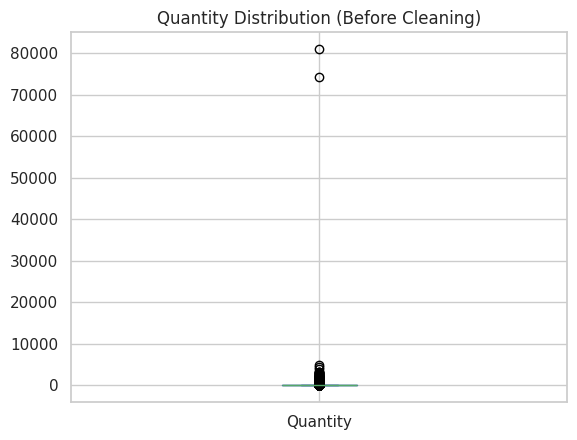

In [115]:
plt.figure()
df['Quantity'].plot(kind='box')
plt.title("Quantity Distribution (Before Cleaning)")
plt.show()

### Outliers in Quantity vs Revenue

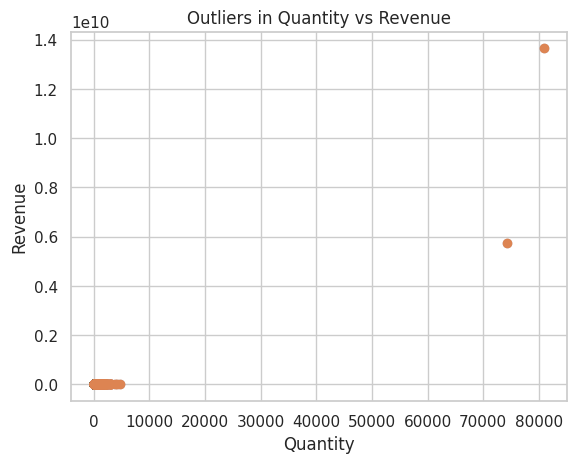

In [116]:
plt.figure()

plt.scatter(df['Quantity'], df['revenue'], alpha=0.3)

plt.scatter(
    outliers['Quantity'],
    outliers['revenue']
)

plt.title("Outliers in Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

### Wholesale vs Retail Customers

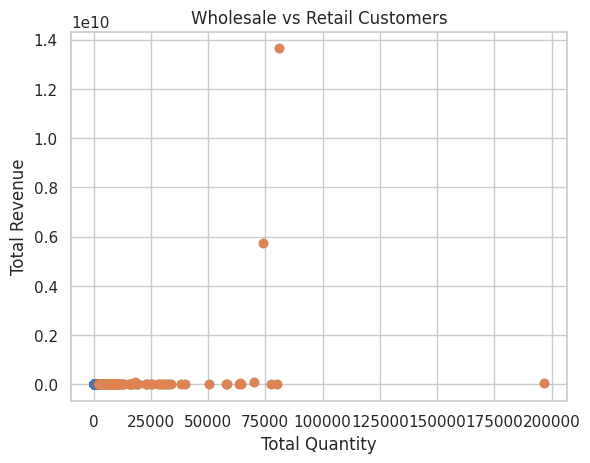

In [117]:
plt.figure()

plt.scatter(
    customer_behavior['Quantity'],
    customer_behavior['revenue'],
    alpha=0.5
)

plt.scatter(
    wholesale_customers['Quantity'],
    wholesale_customers['revenue']
)

plt.title("Wholesale vs Retail Customers")
plt.xlabel("Total Quantity")
plt.ylabel("Total Revenue")

plt.show()

### Creating CSV for RFM Data

In [118]:
# Select only RFM columns
rfm_data = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

# Export to CSV
rfm_data.to_csv('rfm_data.csv', index=False)

print("CSV file created successfully!")

CSV file created successfully!


# **Phase 5: Reporting & Dashboarding in Python**

In this stage, we showcase important business insights through a well-organized dashboard that highlights revenue trends, customer patterns, and product performance for decision-makers.

## **1. Executive Summary Dashboard**

The dashboard brings together key performance indicators (KPIs) into a single, easy-to-understand view:

- Top 10 Products by Revenue Contribution  
- Monthly Revenue Trends (to identify seasonality)  
- Customer Segmentation based on RFM analysis  
- Peak Shopping Hours (visualized through a customer activity heatmap)  

## **2. Visual Storytelling**

- Integrate multiple charts into one dashboard-style layout for better clarity.  
- Each visualization answers a specific business question:

  - Which products contribute the most to revenue?  
  - During which periods does revenue peak?  
  - Which customer segments are the most valuable?  
  - At what times are customers most active?  

- Ensure every chart includes:
  - Descriptive titles  
  - Clearly labeled axes  
  - Relevant annotations to highlight key insights  

## **3. Tools Used**

- **Seaborn** – for creating visually appealing statistical plots  
- **Matplotlib** – for customizing layouts and combining multiple plots into a dashboard  

## **4. Optional Enhancements**

For a more interactive and dynamic experience:

- Use **Plotly** to create interactive charts  
- Build a complete interactive dashboard using **Dash** or **Streamlit**  

### DashBoard Creation

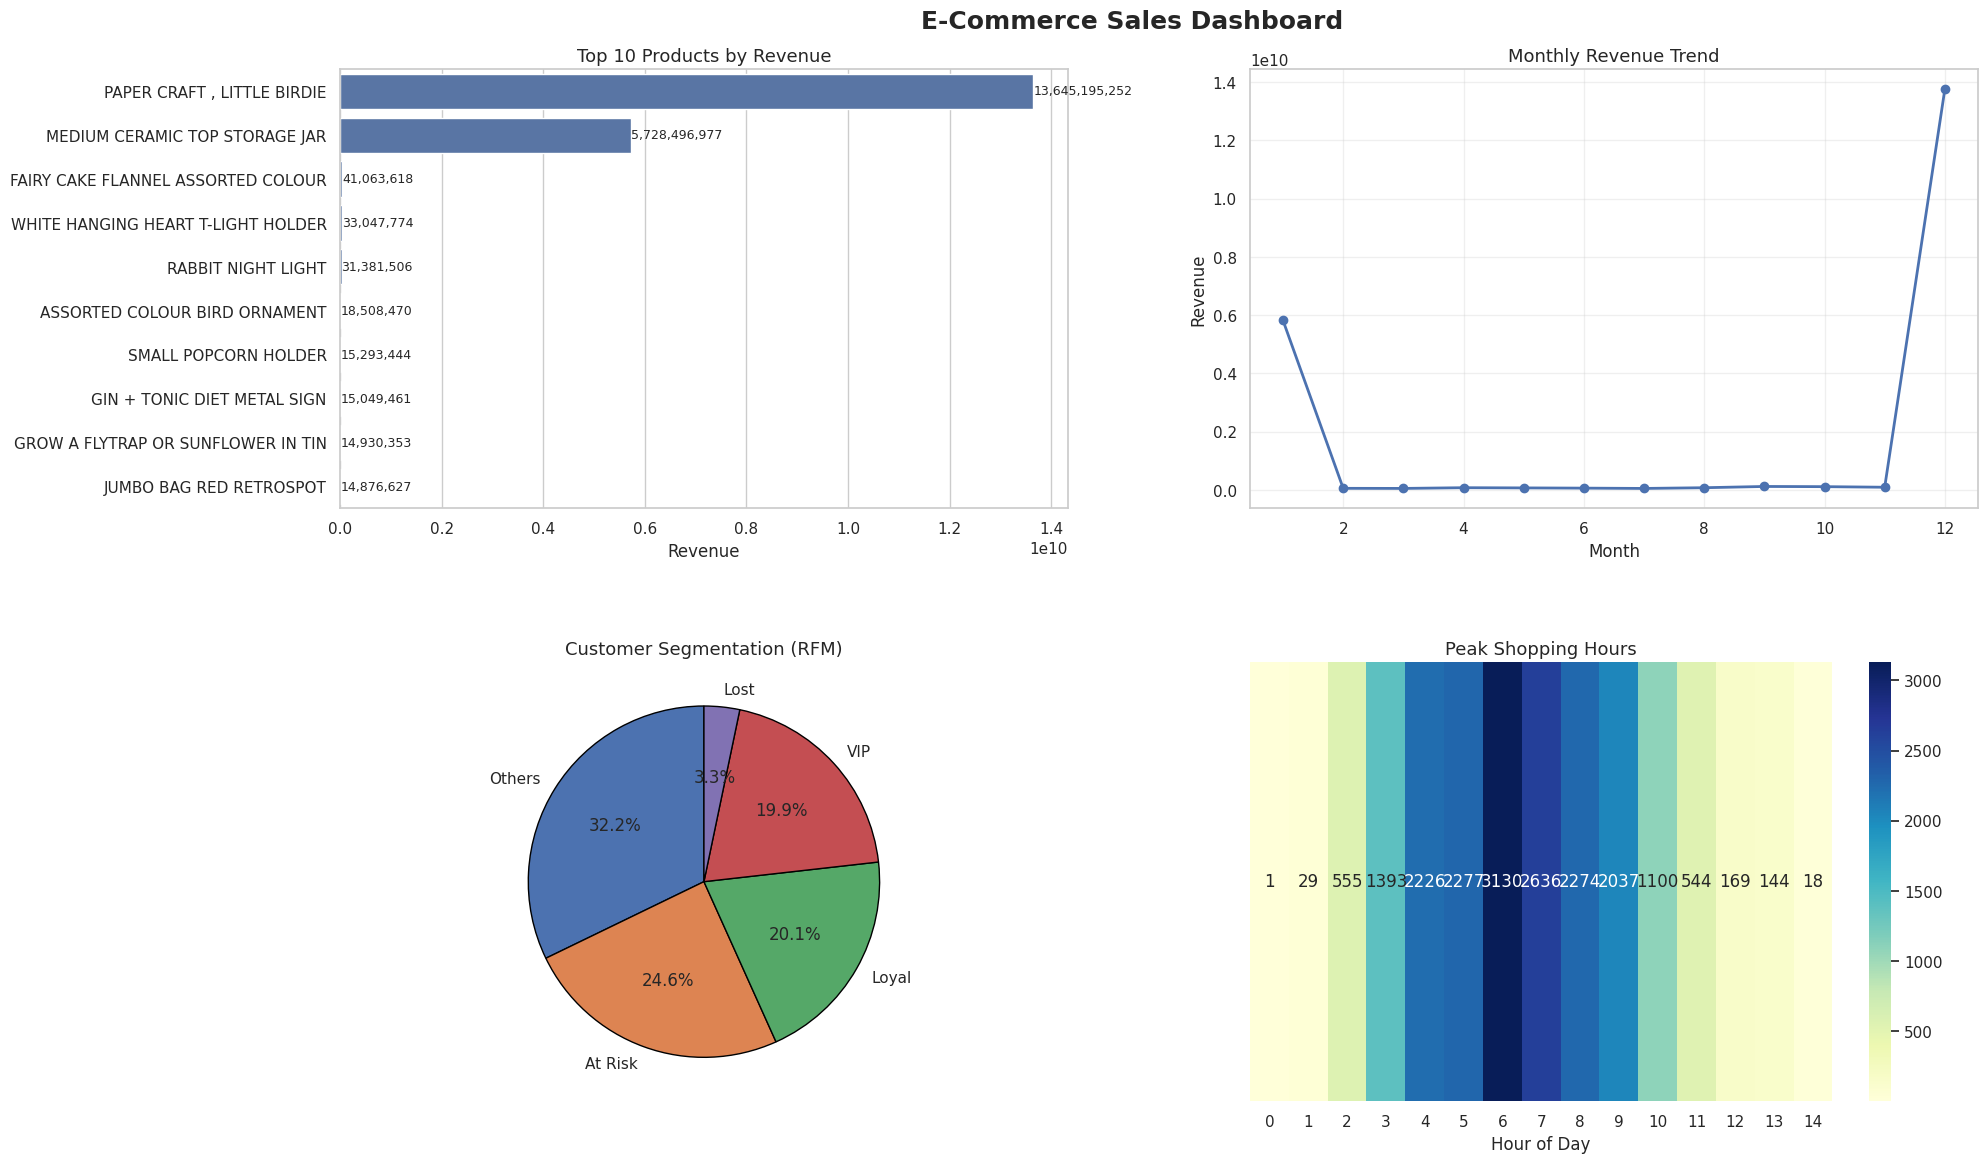

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# STYLE
# =========================
sns.set_theme(style="whitegrid")

# =========================
# DATA PREP
# =========================
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour

# =========================
# RFM CALCULATION
# =========================
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# =========================
# RFM SCORING
# =========================
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# =========================
# SEGMENTATION
# =========================
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP'
    elif f >= 4:
        return 'Loyal'
    elif r <= 2 and f <= 2:
        return 'At Risk'
    elif r == 1:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
segment_counts = rfm['Segment'].value_counts()

# =========================
# DASHBOARD DATA
# =========================
top_products = (
    df.groupby('Description')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

monthly_revenue = (
    df.groupby('Month')['revenue']
    .sum()
    .sort_index()
)

hourly_activity = df.groupby('Hour')['InvoiceNo'].nunique()

# =========================
# DASHBOARD LAYOUT FIXED
# =========================
fig = plt.figure(figsize=(18, 12))

gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

fig.suptitle("E-Commerce Sales Dashboard", fontsize=18, fontweight='bold', y=0.97)

# ==========================================
# 1. TOP PRODUCTS
# ==========================================
sns.barplot(
    data=top_products,
    y='Description',
    x='revenue',
    ax=ax1
)

ax1.set_title("Top 10 Products by Revenue", fontsize=13)
ax1.set_xlabel("Revenue")
ax1.set_ylabel("")

for i, v in enumerate(top_products['revenue']):
    ax1.text(v, i, f"{v:,.0f}", va='center', fontsize=9)

# ==========================================
# 2. MONTHLY TREND
# ==========================================
ax2.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o',
    linewidth=2
)

ax2.set_title("Monthly Revenue Trend", fontsize=13)
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue")
ax2.grid(alpha=0.3)

# ==========================================
# 3. CUSTOMER SEGMENTATION
# ==========================================
ax3.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

ax3.set_title("Customer Segmentation (RFM)", fontsize=13)

# ==========================================
# 4. HEATMAP
# ==========================================
sns.heatmap(
    hourly_activity.values.reshape(1, -1),
    cmap='YlGnBu',
    annot=True,
    fmt='.0f',
    cbar=True,
    ax=ax4
)

ax4.set_title("Peak Shopping Hours", fontsize=13)
ax4.set_xlabel("Hour of Day")
ax4.set_yticks([])

# ==========================================
# FINAL ALIGNMENT
# ==========================================
plt.subplots_adjust(top=0.92, bottom=0.06, left=0.06, right=0.97)

plt.show()